In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp311-cp311-linux_x86_64.whl (780.5 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp311-cp311-linux_x86_64.whl (7.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp311-cp311-linux_x86_64.whl (3.4 MB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl (664.8 MB)
  Using 

In [78]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

GPU Available: True
Device: NVIDIA A100-SXM4-40GB MIG 2g.10gb


In [2]:
import zipfile

with zipfile.ZipFile("slices.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [3]:
import os
os.remove("slices.zip")

In [79]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms.functional as TF
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Configuration ────────────────────────────────────────────────────────────
CFG = {
    'data_dir': './dataset/slices',
    'checkpoint_dir': './checkpoints',  

    # Model
    'num_classes': 5,
    'in_channels': 1,
    'base_features': 32,

    # Training
    'img_size': 256,
    'batch_size': 8,
    'num_epochs': 20,
    'lr': 5e-5,
    'weight_decay': 1e-5,
    'val_split': 0.15,
    'seed': 42,

    # Loss
    'dice_weight': 0.6,
    'bce_weight': 0.4,

    # Misc
    'num_workers': 4,
    'pin_memory': True,
    'use_amp': True,
    'organ_names': ['Liver', 'Spleen', 'Left Kidney', 'Right Kidney', 'Pancreas'],
}

# ── Reproducibility ───────────────────────────────────────────────────────────
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG['seed'])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM   : {total:.1f} GB')

os.makedirs(CFG['checkpoint_dir'], exist_ok=True)

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB MIG 2g.10gb
VRAM   : 10.5 GB


In [158]:
class CTSegDataset(Dataset):
    """
    Expects:
      image_dir/  — *.npy files, each shape (H, W), HU values
      mask_dir/   — *.npy files, each shape (5, H, W), binary {0,1}
    File stems must match between image_dir and mask_dir.
    """
    def __init__(self, image_paths, mask_paths, img_size=256, augment=False):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.img_size    = img_size
        self.augment     = augment
        self.global_mean = None
        self.global_std = None

    def __len__(self):
        return len(self.image_paths)

    def _normalize_ct(self, img: np.ndarray) -> np.ndarray:
        """Clip to soft-tissue window then min-max normalize to [0,1]."""
        img = np.clip(img, -175, 250)   # HU window: abdomen soft tissue
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        return img.astype(np.float32)

    def _augment(self, image: torch.Tensor, mask: torch.Tensor):
        """Joint augmentation — same random transform applied to image AND mask."""
        from torchvision.transforms.functional import InterpolationMode
        # Random horizontal flip
        if random.random() > 0.4:
            image = TF.hflip(image)
            mask  = TF.hflip(mask)

        # Random vertical flip
        if random.random() > 0.4:
            image = TF.vflip(image)
            mask  = TF.vflip(mask)

        # Random rotation ±15°
        if random.random() > 0.4:
            angle = random.uniform(-10, 10)
            image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR)
            mask  = TF.rotate(mask,  angle, interpolation=InterpolationMode.NEAREST)

        return image, mask

    def __getitem__(self, idx):
        image = np.load(self.image_paths[idx])  # (H, W)
        mask  = np.load(self.mask_paths[idx])   # (5, H, W)

        image = self._normalize_ct(image)
        mask  = (mask > 0.5).astype(np.float32)

        # → tensors
        image = torch.from_numpy(image).unsqueeze(0)  # (1, H, W)
        mask  = torch.from_numpy(mask)                # (5, H, W)

        # Resize
        s = self.img_size
        image = F.interpolate(image.unsqueeze(0), (s, s), mode='bilinear', align_corners=False).squeeze(0)
        mask  = F.interpolate(mask.unsqueeze(0),  (s, s), mode='nearest').squeeze(0)

        # Augmentation
        if self.augment:
            image, mask = self._augment(image, mask)

        # ✅ FedGDA (MUST be here, before return)
        if self.global_mean is not None:
            image = (image - image.mean()) / (image.std() + 1e-6)
            image = image * self.global_std + self.global_mean

        # ✅ ONLY return at the end
        return image, mask


def build_loaders(cfg):
    folder = Path(cfg['data_dir'])

    ct_files = sorted(folder.glob('*_ct.npy'))
    mask_files = sorted(folder.glob('*_mask.npy'))

    assert len(ct_files) == len(mask_files) > 0, "Dataset mismatch!"

    n = len(ct_files)
    n_val = int(n * cfg['val_split'])

    indices = list(range(n))
    random.shuffle(indices)

    val_idx = indices[:n_val]
    trn_idx = indices[n_val:]

    trn_imgs = [ct_files[i] for i in trn_idx]
    trn_masks = [mask_files[i] for i in trn_idx]

    val_imgs = [ct_files[i] for i in val_idx]
    val_masks = [mask_files[i] for i in val_idx]

    trn_ds = CTSegDataset(trn_imgs, trn_masks, cfg['img_size'], augment=True)
    val_ds = CTSegDataset(val_imgs, val_masks, cfg['img_size'], augment=False)

    trn_loader = DataLoader(trn_ds, batch_size=cfg['batch_size'], shuffle=True,
                           num_workers=cfg['num_workers'], pin_memory=cfg['pin_memory'],
                           drop_last=True)

    val_loader = DataLoader(val_ds, batch_size=cfg['batch_size'], shuffle=False,
                           num_workers=cfg['num_workers'], pin_memory=cfg['pin_memory'])

    print(f"Train: {len(trn_ds)} | Val: {len(val_ds)}")

    return trn_loader, val_loader


# ── Sanity check (runs without actual data files) ─────────────────────────────
# trn_loader, val_loader = build_loaders(CFG)
print('Dataset class ready — call build_loaders(CFG) once your data paths are set.')

Dataset class ready — call build_loaders(CFG) once your data paths are set.


In [159]:
# ─────────────────────────────────────────────────────────────────────────────
# Building Blocks
# ─────────────────────────────────────────────────────────────────────────────

class DoubleConv(nn.Module):
    """(Conv → BN → ReLU) × 2  — the core U-Net block."""
    def __init__(self, in_ch, out_ch, mid_ch=None):
        super().__init__()
        mid_ch = mid_ch or out_ch
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  mid_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class AttentionGate(nn.Module):
    """
    Soft attention gate from Oktay et al. (2018).
    Learns *where* to focus on the skip-connection features.
    g  = gating signal from decoder (coarser)
    x  = skip connection from encoder (finer)
    """
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1, bias=True),
            nn.BatchNorm2d(F_int),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1, bias=True),
            nn.BatchNorm2d(F_int),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )

    def forward(self, g, x):
        g1  = self.W_g(g)
        x1  = self.W_x(x)
        # upsample g to match x spatial size
        g1  = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        psi = self.psi(F.relu(g1 + x1, inplace=True))
        return x * psi   # attended skip features


# ─────────────────────────────────────────────────────────────────────────────
# Attention U-Net
# ─────────────────────────────────────────────────────────────────────────────

class AttentionUNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=5, base_features=32):
        super().__init__()
        f = base_features   # 32, 64, 128, 256, 512

        # ── Encoder ──────────────────────────────────────────────────────────
        self.enc1 = DoubleConv(in_channels, f)
        self.enc2 = DoubleConv(f,     f*2)
        self.enc3 = DoubleConv(f*2,   f*4)
        self.enc4 = DoubleConv(f*4,   f*8)
        self.pool = nn.MaxPool2d(2)

        # ── Bottleneck ───────────────────────────────────────────────────────
        self.bottleneck = DoubleConv(f*8, f*16)

        # ── Decoder (with attention gates) ───────────────────────────────────
        self.att4 = AttentionGate(F_g=f*16, F_l=f*8,  F_int=f*8)
        self.up4  = nn.ConvTranspose2d(f*16, f*8, 2, stride=2)
        self.dec4 = DoubleConv(f*16, f*8)

        self.att3 = AttentionGate(F_g=f*8,  F_l=f*4,  F_int=f*4)
        self.up3  = nn.ConvTranspose2d(f*8,  f*4, 2, stride=2)
        self.dec3 = DoubleConv(f*8,  f*4)

        self.att2 = AttentionGate(F_g=f*4,  F_l=f*2,  F_int=f*2)
        self.up2  = nn.ConvTranspose2d(f*4,  f*2, 2, stride=2)
        self.dec2 = DoubleConv(f*4,  f*2)

        self.att1 = AttentionGate(F_g=f*2,  F_l=f,    F_int=f)
        self.up1  = nn.ConvTranspose2d(f*2,  f,   2, stride=2)
        self.dec1 = DoubleConv(f*2,  f)

        # ── Output ───────────────────────────────────────────────────────────
        self.out_conv = nn.Conv2d(f, num_classes, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # Encoder
        s1 = self.enc1(x)              # (B, f,   H,   W)
        s2 = self.enc2(self.pool(s1))  # (B, f*2, H/2, W/2)
        s3 = self.enc3(self.pool(s2))  # (B, f*4, H/4, W/4)
        s4 = self.enc4(self.pool(s3))  # (B, f*8, H/8, W/8)

        # Bottleneck
        b  = self.bottleneck(self.pool(s4))  # (B, f*16, H/16, W/16)

        # Decoder with attention
        d4 = self.dec4(torch.cat([self.att4(b,  s4), self.up4(b)],  dim=1))
        d3 = self.dec3(torch.cat([self.att3(d4, s3), self.up3(d4)], dim=1))
        d2 = self.dec2(torch.cat([self.att2(d3, s2), self.up2(d3)], dim=1))
        d1 = self.dec1(torch.cat([self.att1(d2, s1), self.up1(d2)], dim=1))

        return self.out_conv(d1)  # (B, num_classes, H, W) — raw logits


# ── Quick parameter count ─────────────────────────────────────────────────────
model = AttentionUNet(
    in_channels   = CFG['in_channels'],
    num_classes   = CFG['num_classes'],
    base_features = CFG['base_features'],
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters : {total_params:,}   ({total_params/1e6:.1f} M)')

# Estimate VRAM for one batch (fp16)
dummy = torch.randn(CFG['batch_size'], 1, CFG['img_size'], CFG['img_size']).to(DEVICE)
with torch.no_grad(), autocast():
    out = model(dummy)
print(f'Output shape     : {tuple(out.shape)}')
print(f'Peak VRAM        : {torch.cuda.max_memory_allocated()/1e9:.2f} GB')
del dummy, out
torch.cuda.empty_cache()

Model parameters : 8,027,089   (8.0 M)
Output shape     : (8, 5, 256, 256)
Peak VRAM        : 8.60 GB


In [160]:
class DiceLoss(nn.Module):
    """
    Soft Dice loss — works per-channel then averages.
    Handles class imbalance natively (organs are tiny vs background).
    """
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)        # (B, C, H, W)
        B, C = probs.shape[:2]
        probs   = probs.view(B, C, -1)       # (B, C, N)
        targets = targets.view(B, C, -1)

        intersection = (probs * targets).sum(dim=2)            # (B, C)
        dice = (2 * intersection + self.smooth) / \
               (probs.sum(dim=2) + targets.sum(dim=2) + self.smooth)
        return 1.0 - dice.mean()


class CombinedLoss(nn.Module):
    """
    Combined Dice + Binary Cross-Entropy loss.
    - Dice: handles class imbalance, directly optimizes the Dice metric
    - BCE:  provides stable gradients at the start of training
    """
    def __init__(self, dice_weight=0.6, bce_weight=0.4):
        super().__init__()
        self.dice     = DiceLoss()
        self.bce      = nn.BCEWithLogitsLoss()
        self.dw       = dice_weight
        self.bw       = bce_weight

    def forward(self, logits, targets):
        return self.dw * self.dice(logits, targets) + \
               self.bw * self.bce(logits, targets)


# ── Dice metric (for evaluation — hard predictions) ───────────────────────────
@torch.no_grad()
def dice_score(logits, targets, threshold=0.5, eps=1e-8):
    """
    Returns per-class and mean Dice scores.
    logits  : (B, C, H, W)  — raw model output
    targets : (B, C, H, W)  — binary ground truth
    """
    preds   = (torch.sigmoid(logits) > threshold).float()
    B, C    = preds.shape[:2]
    preds   = preds.view(B, C, -1)
    targets = targets.view(B, C, -1)

    intersection = (preds * targets).sum(dim=2)              # (B, C)
    dice = (2 * intersection + eps) / \
           (preds.sum(dim=2) + targets.sum(dim=2) + eps)
    per_class = dice.mean(dim=0)   # (C,)
    mean_dice = per_class.mean()   # scalar
    return per_class, mean_dice


criterion = CombinedLoss(CFG['dice_weight'], CFG['bce_weight'])
print('Loss function ready.')

Loss function ready.


In [161]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = CFG['lr'],
    weight_decay = CFG['weight_decay'],
)

# Cosine annealing — smoothly decays LR over training
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max  = CFG['num_epochs'],
    eta_min= 1e-6,
)

# Mixed-precision scaler (fp16 — halves VRAM, 2-3× faster on A100)
scaler = GradScaler(enabled=CFG['use_amp'])

print('Optimizer : AdamW')
print('Scheduler : CosineAnnealingLR')
print(f'AMP       : {CFG["use_amp"]}')

Optimizer : AdamW
Scheduler : CosineAnnealingLR
AMP       : True


In [162]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = 0.0
    per_class_dice = torch.zeros(CFG['num_classes'])

    pbar = tqdm(loader, desc='  Train', leave=False)
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=CFG['use_amp']):
            logits = model(images)
            loss   = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        pc, md = dice_score(logits.detach(), masks)
        per_class_dice += pc.cpu()

        pbar.set_postfix(loss=f'{loss.item():.4f}', dice=f'{md.item():.4f}')

    n = len(loader)
    return total_loss / n, per_class_dice / n


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    per_class_dice = torch.zeros(CFG['num_classes'])

    pbar = tqdm(loader, desc='  Val  ', leave=False)
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        with autocast(enabled=CFG['use_amp']):
            logits = model(images)
            loss   = criterion(logits, masks)

        total_loss += loss.item()
        pc, _ = dice_score(logits, masks)
        per_class_dice += pc.cpu()

    n = len(loader)
    return total_loss / n, per_class_dice / n


print('Train / validate functions ready.')

Train / validate functions ready.


In [163]:
# ── Main Training Loop ────────────────────────────────────────────────────────

# ❗ Build loaders (point to your actual data)
trn_loader, val_loader = build_loaders(CFG)

history = {'trn_loss': [], 'val_loss': [], 'trn_dice': [], 'val_dice': []}
best_dice = 0.0
best_ckpt = Path(CFG['checkpoint_dir']) / 'best_model.pth'

print(f'Starting training for {CFG["num_epochs"]} epochs\n')

for epoch in range(1, CFG['num_epochs'] + 1):
    trn_loss, trn_pc = train_one_epoch(model, trn_loader, optimizer, criterion, scaler, DEVICE)
    val_loss, val_pc = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    trn_dice = trn_pc.mean().item()
    val_dice = val_pc.mean().item()

    history['trn_loss'].append(trn_loss)
    history['val_loss'].append(val_loss)
    history['trn_dice'].append(trn_dice)
    history['val_dice'].append(val_dice)

    # Save best checkpoint
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save({
            'epoch':      epoch,
            'state_dict': model.state_dict(),
            'optimizer':  optimizer.state_dict(),
            'val_dice':   val_dice,
            'cfg':        CFG,
        }, best_ckpt)
        flag = '  ← best'
    else:
        flag = ''

    lr_now = optimizer.param_groups[0]['lr']
    per = '  '.join([f'{CFG["organ_names"][i][0]}.{val_pc[i]:.3f}' for i in range(CFG['num_classes'])])
    print(f'Ep {epoch:03d}/{CFG["num_epochs"]} │ '
          f'trn {trn_loss:.4f}/{trn_dice:.4f} │ '
          f'val {val_loss:.4f}/{val_dice:.4f} │ '
          f'lr {lr_now:.1e} │ [{per}]{flag}')

Train: 9208 | Val: 1624
Starting training for 20 epochs



  Train:   0%|          | 0/1151 [00:00<?, ?it/s]

  Val  :   0%|          | 0/203 [00:00<?, ?it/s]

Ep 001/20 │ trn 0.6391/0.2092 │ val 0.5790/0.3392 │ lr 5.0e-05 │ [L.0.693  S.0.029  L.0.036  R.0.315  P.0.624]  ← best


  Train:   0%|          | 0/1151 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/203 [00:00<?, ?it/s]

Ep 019/20 │ trn 0.0822/0.9077 │ val 0.0863/0.9002 │ lr 1.3e-06 │ [L.0.911  S.0.924  L.0.820  R.0.923  P.0.924]  ← best


  Train:   0%|          | 0/1151 [00:00<?, ?it/s]

  Val  :   0%|          | 0/203 [00:00<?, ?it/s]

Ep 020/20 │ trn 0.0803/0.9090 │ val 0.0850/0.9008 │ lr 1.0e-06 │ [L.0.917  S.0.922  L.0.819  R.0.921  P.0.925]  ← best


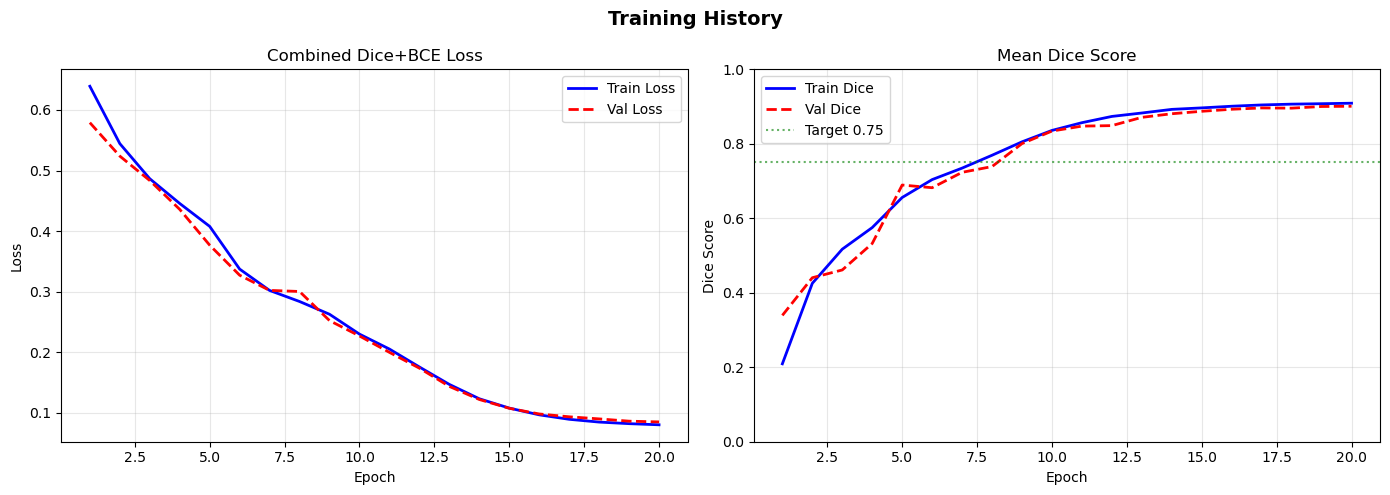

Best Validation Dice : 0.9008


In [164]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

epochs = range(1, len(history['trn_loss']) + 1)

ax1.plot(epochs, history['trn_loss'], 'b-',  label='Train Loss', linewidth=2)
ax1.plot(epochs, history['val_loss'], 'r--', label='Val Loss',   linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Combined Dice+BCE Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['trn_dice'], 'b-',  label='Train Dice', linewidth=2)
ax2.plot(epochs, history['val_dice'], 'r--', label='Val Dice',   linewidth=2)
ax2.axhline(0.75, color='green', linestyle=':', alpha=0.6, label='Target 0.75')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Dice Score'); ax2.set_title('Mean Dice Score')
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best Validation Dice : {best_dice:.4f}')

In [165]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
ckpt = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt['state_dict'])
print(f'Loaded checkpoint from epoch {ckpt["epoch"]} (val_dice={ckpt["val_dice"]:.4f})')

# ── Full validation evaluation ────────────────────────────────────────────────
model.eval()
all_dice = torch.zeros(CFG['num_classes'])
n_batches = 0

with torch.no_grad():
    for images, masks in tqdm(val_loader, desc='Evaluating'):
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)
        with autocast(enabled=CFG['use_amp']):
            logits = model(images)
        pc, _ = dice_score(logits, masks)
        all_dice += pc.cpu()
        n_batches += 1

all_dice /= n_batches
print('\n── Per-Organ Dice Scores ──────────────────────')
for i, name in enumerate(CFG['organ_names']):
    bar = '█' * int(all_dice[i] * 30)
    print(f'  {name:<15} {all_dice[i]:.4f}  {bar}')
print(f'  {"Mean":<15} {all_dice.mean():.4f}')

Loaded checkpoint from epoch 20 (val_dice=0.9008)


Evaluating:   0%|          | 0/203 [00:00<?, ?it/s]


── Per-Organ Dice Scores ──────────────────────
  Liver           0.9170  ███████████████████████████
  Spleen          0.9219  ███████████████████████████
  Left Kidney     0.8193  ████████████████████████
  Right Kidney    0.9215  ███████████████████████████
  Pancreas        0.9245  ███████████████████████████
  Mean            0.9008


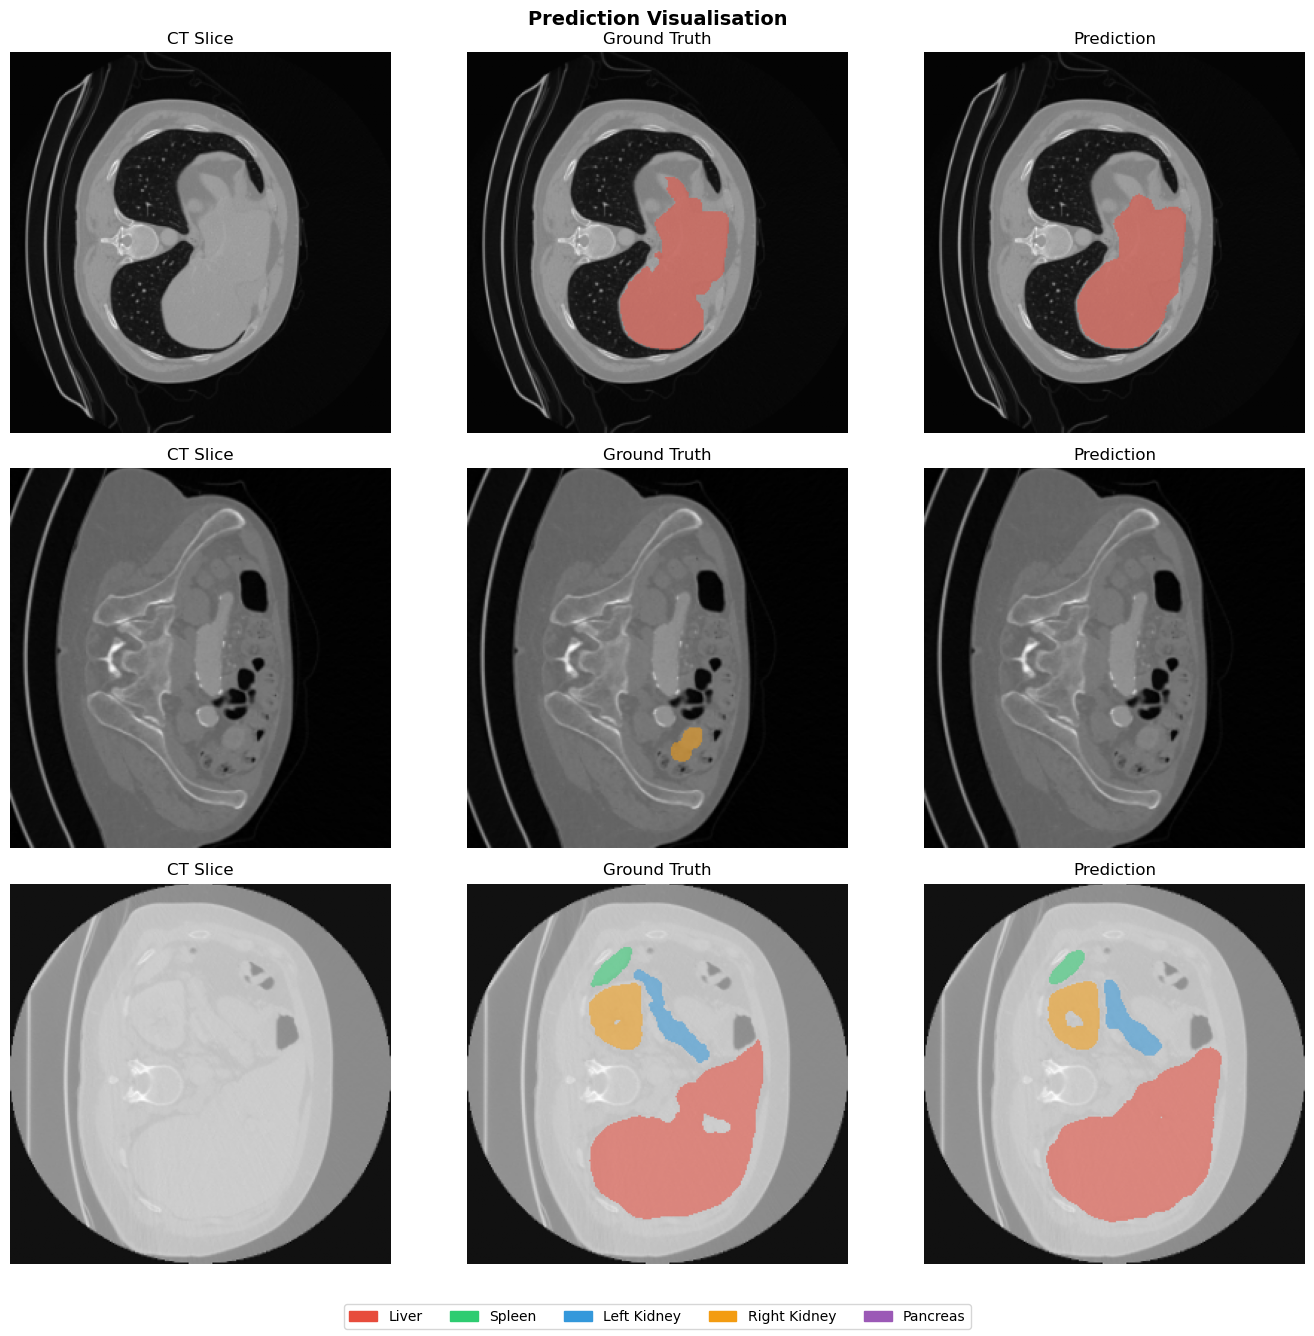

In [166]:
# ── Visual Prediction Check ───────────────────────────────────────────────────
COLORS = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']

def visualize_predictions(model, loader, device, num_samples=3):
    model.eval()
    images, masks = next(iter(loader))
    images = images.to(device)

    with torch.no_grad(), autocast(enabled=CFG['use_amp']):
        logits = model(images)
    preds = (torch.sigmoid(logits) > 0.5).cpu().float()

    num_samples = min(num_samples, images.shape[0])
    fig, axes = plt.subplots(num_samples, 3, figsize=(14, 4.5 * num_samples))
    if num_samples == 1: axes = axes[np.newaxis, :]

    for i in range(num_samples):
        img_np = images[i, 0].cpu().numpy()

        # CT image
        axes[i, 0].imshow(img_np, cmap='gray')
        axes[i, 0].set_title('CT Slice'); axes[i, 0].axis('off')

        # Ground truth overlay
        axes[i, 1].imshow(img_np, cmap='gray')
        for c in range(CFG['num_classes']):
            mask_c = masks[i, c].numpy()
            rgba = np.zeros((*mask_c.shape, 4))
            r, g, b = tuple(int(COLORS[c][j:j+2], 16)/255 for j in (1,3,5))
            rgba[..., :3] = [r, g, b]
            rgba[..., 3]  = mask_c * 0.55
            axes[i, 1].imshow(rgba)
        axes[i, 1].set_title('Ground Truth'); axes[i, 1].axis('off')

        # Prediction overlay
        axes[i, 2].imshow(img_np, cmap='gray')
        for c in range(CFG['num_classes']):
            pred_c = preds[i, c].numpy()
            rgba = np.zeros((*pred_c.shape, 4))
            r, g, b = tuple(int(COLORS[c][j:j+2], 16)/255 for j in (1,3,5))
            rgba[..., :3] = [r, g, b]
            rgba[..., 3]  = pred_c * 0.55
            axes[i, 2].imshow(rgba)
        axes[i, 2].set_title('Prediction'); axes[i, 2].axis('off')

    patches = [mpatches.Patch(color=COLORS[c], label=CFG['organ_names'][c])
               for c in range(CFG['num_classes'])]
    fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=10, framealpha=0.8)
    plt.suptitle('Prediction Visualisation', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(model, val_loader, DEVICE)

In [167]:
torch.save(model.state_dict(), "baseline_model.pth")
print("Baseline model saved")

Baseline model saved


In [168]:
model = AttentionUNet(
    in_channels=CFG['in_channels'],
    num_classes=CFG['num_classes']
).to(DEVICE)

model.load_state_dict(torch.load("baseline_model.pth"))
print("Model loaded")

Model loaded


In [169]:
trn_loader, val_loader = build_loaders(CFG)

train_dataset = trn_loader.dataset

print("Train dataset:", len(train_dataset))

Train: 9208 | Val: 1624
Train dataset: 9208


In [170]:
from torch.utils.data import DataLoader, Subset
def dirichlet_partition(dataset, num_clients=3, alpha=0.5, seed=42):
    import numpy as np
    from collections import defaultdict
    

    rng = np.random.default_rng(seed)

    class_indices = defaultdict(list)

    # ✅ FIXED LOOP
    for idx in range(len(dataset)):
        _, mask = dataset[idx]

        mask_np = mask.numpy() if hasattr(mask, 'numpy') else np.array(mask)

        # Convert one-hot → class index
        if mask_np.ndim == 3:
            mask_np = np.argmax(mask_np, axis=0)

        dominant = int(np.bincount(mask_np.flatten()).argmax())

        class_indices[dominant].append(idx)   # ✅ IMPORTANT

    client_indices = [[] for _ in range(num_clients)]  # ✅ IMPORTANT

    for cls, indices in class_indices.items():
        rng.shuffle(indices)

        proportions = rng.dirichlet(alpha=np.repeat(alpha, num_clients))
        proportions = (np.cumsum(proportions) * len(indices)).astype(int)

        splits = np.split(indices, proportions[:-1])

        for c, split in enumerate(splits):
            client_indices[c].extend(split.tolist())

    return client_indices

def make_client_loaders(dataset, num_clients=3, batch_size=8, alpha=0.5):
    """Returns list of DataLoaders, one per client."""
    partitions = dirichlet_partition(dataset, num_clients=num_clients, alpha=alpha)
    loaders = []
    for i, indices in enumerate(partitions):
        subset = Subset(dataset, indices)
        loader = DataLoader(subset, batch_size=batch_size, shuffle=True,
                            num_workers=2, pin_memory=True)
        print(f"  Client {i+1}: {len(indices)} samples")
        loaders.append(loader)
    return loaders

In [171]:
client_loaders = make_client_loaders(train_dataset, num_clients=3, alpha=1.5)

print("Clients ready:", len(client_loaders))

  Client 1: 1020 samples
  Client 2: 3226 samples
  Client 3: 4962 samples
Clients ready: 3


In [172]:
# federated_client.py
import copy
import torch
from torch.cuda.amp import autocast, GradScaler

def train_one_client(model, dataloader, device, num_epochs=1, lr=1e-4):
    import copy
    import torch
    from torch.cuda.amp import autocast, GradScaler
    import torch.nn.functional as F

    local_model = copy.deepcopy(model).to(device)
    optimizer = torch.optim.AdamW(local_model.parameters(), lr=lr, weight_decay=1e-5)
    scaler = GradScaler(enabled=(device.type == "cuda"))
    criterion = dice_bce_loss

    local_model.train()
    total_loss = 0.0
    steps = 0

    # 🔥 Stats accumulators
    sum_feat = None
    sum_sq_feat = None
    count = 0

    for epoch in range(num_epochs):
        for images, masks in dataloader:
            images = images.to(device, non_blocking=True)
            masks  = masks.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=(device.type == "cuda")):
                preds = local_model(images)
                loss  = criterion(preds, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            steps += 1

            # 🔥 Feature extraction (safe)
            feat = preds.detach().view(preds.size(0), -1)

            # 🔥 Normalize features (VERY IMPORTANT)
            feat = F.normalize(feat, dim=1)

            # 🔥 Initialize or accumulate
            if sum_feat is None:
                sum_feat = feat.sum(dim=0)
                sum_sq_feat = (feat ** 2).sum(dim=0)
            else:
                sum_feat += feat.sum(dim=0)
                sum_sq_feat += (feat ** 2).sum(dim=0)

            count += feat.size(0)

    # 🔥 Average loss
    avg_loss = total_loss / max(steps, 1)

    # 🔥 Compute mean
    c_mean = sum_feat / count

    # 🔥 Stable variance computation
    var = sum_sq_feat / count - c_mean ** 2
    var = torch.clamp(var, min=1e-8)   # ⭐ prevents negative / inf

    # 🔥 Standard deviation
    c_std = torch.sqrt(var)

    return local_model.state_dict(), avg_loss, c_mean, c_std

In [173]:
# federated_aggregation.py
import torch
import copy

def fedavg(global_model, client_state_dicts, client_sizes):
    """
    Federated averaging (McMahan et al., 2017).
    client_state_dicts : list of OrderedDicts from each client
    client_sizes       : list of ints (number of samples per client)
    Returns new aggregated state_dict.
    """
    total = sum(client_sizes)
    weights = [n / total for n in client_sizes]

    agg_state = copy.deepcopy(client_state_dicts[0])

    for key in agg_state:
        agg_state[key] = sum(
            w * sd[key].to(agg_state[key].device)
            for w, sd in zip(weights, client_state_dicts)
        )

    global_model.load_state_dict(agg_state)
    return global_model

In [174]:
# federated_train.py
import torch
import copy
from collections import defaultdict

def federated_train(
    global_model,
    client_loaders,
    val_loader,
    device,
    num_rounds=15,
    local_epochs=1,
    lr=3e-5,
):
    """
    Full federated training loop.
    Returns history dict with per-round metrics.
    """
    history = defaultdict(list)
    global_model = global_model.to(device)

    for rnd in range(1, num_rounds + 1):
        print(f"\n{'='*50}")
        print(f"  Round {rnd}/{num_rounds}")
        print(f"{'='*50}")

        client_states = []
        client_sizes = []
        client_means = []
        client_stds = []
        round_losses = []

        # ── 1. Distribute global weights & train each client ──────────────
        for i, loader in enumerate(client_loaders):
            state_dict, client_loss,c_mean,c_std = train_one_client(
                model=global_model,
                dataloader=loader,
                device=device,
                num_epochs=local_epochs,
                lr=lr,
            )
            print(f"  Client {i+1}: loss={client_loss:.4f}  "
                  f"samples={len(loader.dataset)}")
            print(f"    mean norm: {c_mean.norm().item():.4f}")
            print(f"    std  norm: {c_std.norm().item():.4f}")
            client_states.append(state_dict)
            client_sizes.append(len(loader.dataset))
            client_means.append(c_mean.cpu())
            client_stds.append(c_std.cpu())
            round_losses.append(client_loss)
            

        # ── 2. Aggregate ──────────────────────────────────────────────────
        global_model = fedavg(global_model, client_states, client_sizes)
        
        global_mean = torch.stack(client_means).mean(dim=0).detach()
        global_std  = torch.stack(client_stds).mean(dim=0).detach()
        # ── 2.1 Send stats back to clients ───────────────────────
        for loader in client_loaders:
            loader.dataset.global_mean = global_mean
            loader.dataset.global_std  = global_std

        # ── 3. Evaluate global model ──────────────────────────────────────
        with torch.no_grad():
            val_loss, per_class = validate(global_model, val_loader, criterion, device)
            val_dice = per_class.mean().item()

        avg_loss = sum(round_losses) / len(round_losses)
        history['round'].append(rnd)
        history['avg_client_loss'].append(avg_loss)
        history['val_dice'].append(val_dice)
        history['per_class_dice'].append(per_class)

        print(f"\n  [Round {rnd}] Avg client loss : {avg_loss:.4f}")
        print(f"  [Round {rnd}] Val Dice (mean) : {val_dice:.4f}")
        class_names = ['Liver', 'Spleen', 'Left Kidney', 'Right Kidney', 'Pancreas']
        for cls, d in zip(class_names, per_class):
            print(f"    {cls:<12}: {d:.4f}")

    return global_model, history

In [175]:
# federated_eval.py
import torch
import numpy as np

@torch.no_grad()
def evaluate_model(model, val_loader, device, num_classes=5):
    """
    Computes mean Dice and per-class Dice on the validation set.
    Assumes masks are integer class maps (0..num_classes-1).
    """
    model.eval()
    model.to(device)

    dice_per_class = torch.zeros(num_classes, device=device)
    count = 0

    for images, masks in val_loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        # Convert one-hot → class index
        if masks.ndim == 4:
            masks = masks.argmax(dim=1)

        preds = model(images)                      # (B, C, H, W)
        preds = torch.softmax(preds, dim=1)
        pred_classes = preds.argmax(dim=1)         # (B, H, W)

        for cls in range(num_classes):
            pred_c = (pred_classes == cls).float()
            true_c = (masks == cls).float()
            intersection = (pred_c * true_c).sum()
            denom = pred_c.sum() + true_c.sum() + 1e-6
            dice_per_class[cls] += 2.0 * intersection / denom

        count += 1

    dice_per_class /= max(count, 1)
    mean_dice = dice_per_class[1:].mean()          # skip background
    return mean_dice.item(), dice_per_class.cpu().tolist()

In [176]:
import torch
import torch.nn.functional as F

def dice_bce_loss(preds, targets, smooth=1e-6):
    preds = torch.sigmoid(preds)

    intersection = (preds * targets).sum(dim=(2,3))
    dice = (2. * intersection + smooth) / (preds.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + smooth)
    dice_loss = 1 - dice.mean()

    bce = F.binary_cross_entropy_with_logits(preds, targets)

    return dice_loss + bce

Device: cuda
Baseline model loaded.
Train: 9208 | Val: 1624

Partitioning dataset into 3 non-IID clients (α=2.0)...
  Client 1: 1267 samples
  Client 2: 3248 samples
  Client 3: 4693 samples


  Val  :   0%|          | 0/203 [00:00<?, ?it/s]


Baseline (centralized) Val Dice: 0.9069

  Round 1/15
  Client 1: loss=1.2741  samples=1267
    mean norm: 0.9844
    std  norm: 0.1785
  Client 2: loss=1.1973  samples=3248
    mean norm: 0.9839
    std  norm: 0.2096
  Client 3: loss=1.1716  samples=4693
    mean norm: 0.9697
    std  norm: 0.2546


  Val  :   0%|          | 0/203 [00:00<?, ?it/s]


  [Round 1] Avg client loss : 1.2143
  [Round 1] Val Dice (mean) : 0.8753
    Liver       : 0.9067
    Spleen      : 0.8682
    Left Kidney : 0.7677
    Right Kidney: 0.9147
    Pancreas    : 0.9191

  Round 2/15
  Client 1: loss=1.1273  samples=1267
    mean norm: 0.9839
    std  norm: 0.1813
  Client 2: loss=1.1274  samples=3248
    mean norm: 0.9849
    std  norm: 0.2064
  Client 3: loss=1.1209  samples=4693
    mean norm: 0.9702
    std  norm: 0.2578


...


  [Round 13] Avg client loss : 1.1132
  [Round 13] Val Dice (mean) : 0.8370
    Liver       : 0.8910
    Spleen      : 0.7788
    Left Kidney : 0.7303
    Right Kidney: 0.8784
    Pancreas    : 0.9063

  Round 14/15
  Client 1: loss=1.1152  samples=1267
    mean norm: 0.9800
    std  norm: 0.2008
  Client 2: loss=1.1158  samples=3248
    mean norm: 0.9829
    std  norm: 0.2064
  Client 3: loss=1.1098  samples=4693
    mean norm: 0.9731
    std  norm: 0.2498


  Val  :   0%|          | 0/203 [00:00<?, ?it/s]


  [Round 14] Avg client loss : 1.1136
  [Round 14] Val Dice (mean) : 0.8361
    Liver       : 0.8741
    Spleen      : 0.7724
    Left Kidney : 0.7417
    Right Kidney: 0.8730
    Pancreas    : 0.9193

  Round 15/15
  Client 1: loss=1.1118  samples=1267
    mean norm: 0.9800
    std  norm: 0.1993
  Client 2: loss=1.1143  samples=3248
    mean norm: 0.9824
    std  norm: 0.2075
  Client 3: loss=1.1115  samples=4693
    mean norm: 0.9731
    std  norm: 0.2500


  Val  :   0%|          | 0/203 [00:00<?, ?it/s]


  [Round 15] Avg client loss : 1.1126
  [Round 15] Val Dice (mean) : 0.8467
    Liver       : 0.8991
    Spleen      : 0.7700
    Left Kidney : 0.7556
    Right Kidney: 0.8882
    Pancreas    : 0.9205
Federated model saved.

Best Federated Dice: 0.8753


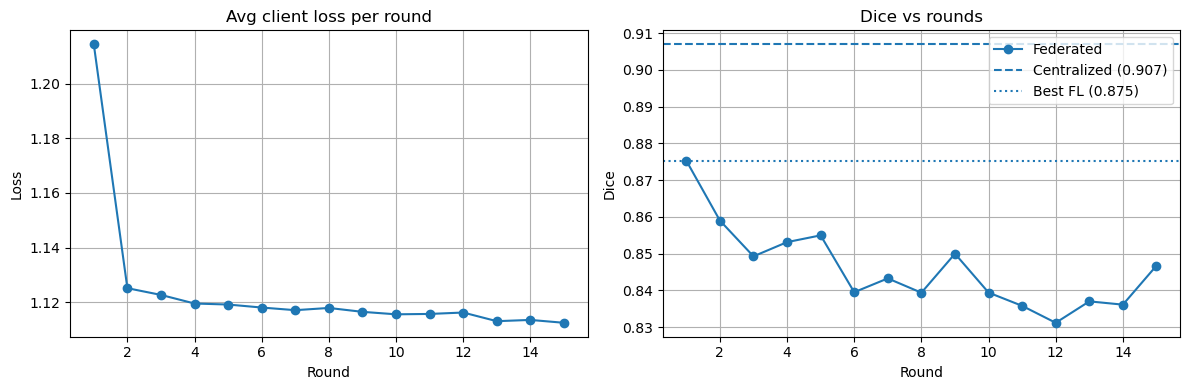

  Val  :   0%|          | 0/203 [00:00<?, ?it/s]


── Final comparison ───────────────────────────────
Class               Centralized    Federated
---------------------------------------------
Liver                    0.9205       0.8991
Spleen                   0.9249       0.7700
Left Kidney              0.8302       0.7556
Right Kidney             0.9329       0.8882
Pancreas                 0.9263       0.9205
---------------------------------------------
Mean Dice                0.9069       0.8467


In [178]:
# ── Cell 1: Imports and config ────────────────────────────────────────────
import torch
import matplotlib.pyplot as plt

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLIENTS = 3
NUM_ROUNDS  = 15
BATCH_SIZE  = 8
ALPHA       = 2.0

print(f"Device: {DEVICE}")

# ── Cell 2: Load baseline model ───────────────────────────────────────────
global_model = AttentionUNet(in_channels=1, num_classes=5)
global_model.load_state_dict(torch.load('baseline_model.pth', map_location=DEVICE))
global_model = global_model.to(DEVICE)

print("Baseline model loaded.")

# ── Cell 3: Load datasets ─────────────────────────────────────────────────
trn_loader, val_loader = build_loaders(CFG)
train_dataset = trn_loader.dataset

# Non-IID partition
print(f"\nPartitioning dataset into {NUM_CLIENTS} non-IID clients (α={ALPHA})...")
client_loaders = make_client_loaders(
    train_dataset,
    num_clients=NUM_CLIENTS,
    batch_size=BATCH_SIZE,
    alpha=ALPHA
)

# ── Cell 4: Baseline evaluation (CORRECT) ─────────────────────────────────
criterion = dice_bce_loss

val_loss, per_class = validate(global_model, val_loader, criterion, DEVICE)
baseline_dice = per_class.mean().item()
baseline_per_class = per_class

print(f"\nBaseline (centralized) Val Dice: {baseline_dice:.4f}")

# ── Cell 5: Federated training ────────────────────────────────────────────
fed_model, history = federated_train(
    global_model   = global_model,
    client_loaders = client_loaders,
    val_loader     = val_loader,
    device         = DEVICE,
    num_rounds     = NUM_ROUNDS,
    local_epochs   = 1,
    lr             = 3e-5,
)

# ── Cell 6: Save federated model ──────────────────────────────────────────
torch.save(fed_model.state_dict(), 'federated_model.pth')
print("Federated model saved.")

# ── Cell 7: Plot learning curves ──────────────────────────────────────────
rounds = history['round']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(rounds, history['avg_client_loss'], marker='o')
axes[0].set_title('Avg client loss per round')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Loss')
axes[0].grid()

best_fed_dice = max(history['val_dice'])
print(f"\nBest Federated Dice: {best_fed_dice:.4f}")
axes[1].plot(rounds, history['val_dice'], marker='o', label='Federated')
axes[1].axhline(baseline_dice, linestyle='--', label=f'Centralized ({baseline_dice:.3f})')
axes[1].axhline(best_fed_dice, linestyle=':', label=f'Best FL ({best_fed_dice:.3f})')
axes[1].set_title('Dice vs rounds')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Dice')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.savefig('federated_vs_baseline.png')
plt.show()

# ── Cell 8: Final comparison ──────────────────────────────────────────────
val_loss, per_class = validate(fed_model, val_loader, criterion, DEVICE)
final_dice = per_class.mean().item()
final_per_class = per_class

class_names = ['Liver', 'Spleen', 'Left Kidney', 'Right Kidney', 'Pancreas']

print("\n── Final comparison ───────────────────────────────")
print(f"{'Class':<18} {'Centralized':>12} {'Federated':>12}")
print("-" * 45)

for cls, b, f in zip(class_names, baseline_per_class, final_per_class):
    print(f"{cls:<18} {b:>12.4f} {f:>12.4f}")

print("-" * 45)
print(f"{'Mean Dice':<18} {baseline_dice:>12.4f} {final_dice:>12.4f}")